## HISTOGRAMA DE UNA IMAGEN CONTRASTADA

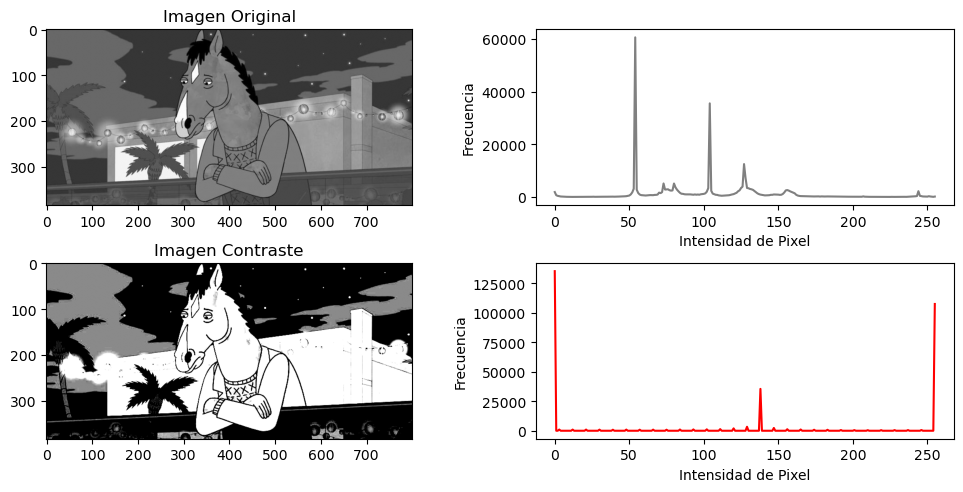

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
 
def contraste (img,factor=1.0):
    img=img.astype(np.float32) 
    media=np.mean(img)
    img_contraste=media+(img-media)*factor
    img_contraste=np.clip(img_contraste,0,255).astype(np.uint8)
    return img_contraste    

img=cv2.imread('imagen1.jpg',0) #sin colores quitar el cv2.IMREAD_GRAYSCALE
contrast=9
img_fin=contraste(img,contrast)

## calculo de histograma
histograma_ori=cv2.calcHist([img],[0],None,[256],[0,256])
histograma_new=cv2.calcHist([img_fin],[0],None,[256],[0,256])

## el ploteado cambia al plotear el histograsma
plt.figure(figsize=(10,5))
plt.subplot(221)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.subplot(222)
plt.plot(histograma_ori ,color='gray')
plt.xlabel('Intensidad de Pixel')
plt.ylabel('Frecuencia')
plt.subplot(223)
plt.imshow(img_fin,cmap='gray')
plt.title('Imagen Contraste')
plt.subplot(224)
plt.plot(histograma_new ,color='red')
plt.xlabel('Intensidad de Pixel')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()



## E-1 CALCULAR EL HISTOGRAMA DE UN PUNTO DE INTERES DE UNA IMAGEN A COLORES

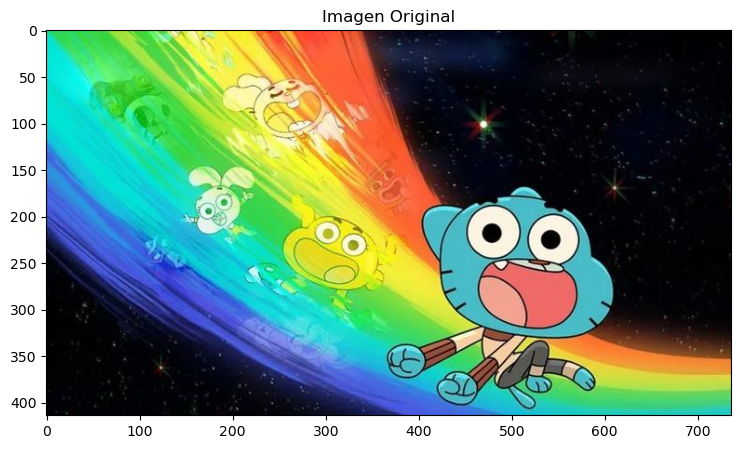

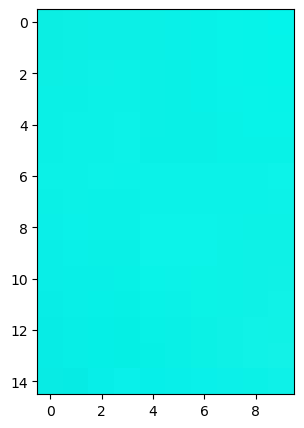

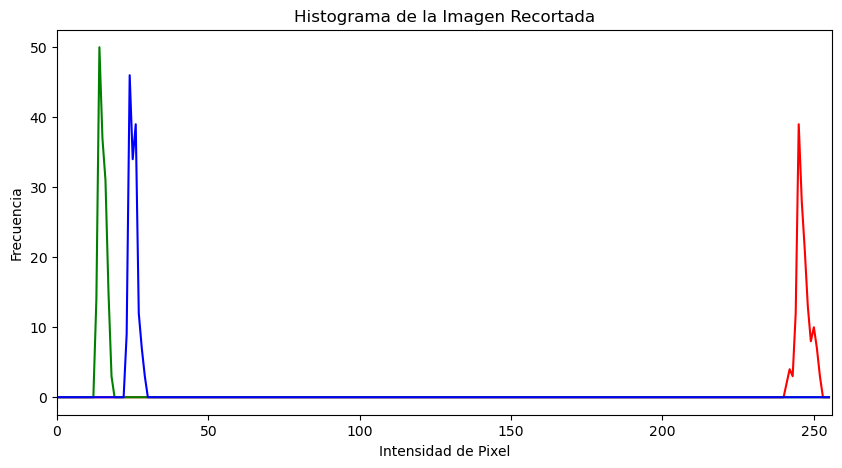

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imge=cv2.imread('gumball.jpg')
img_rgb=cv2.cvtColor(imge,cv2.COLOR_BGR2RGB)

plt.rcParams['figure.figsize'] = (10, 5)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.show()

plt.imshow(img_rgb[50:65,20:30,:])
plt.show()

img_recortada=img_rgb[50:65,20:30,:]
plt.imsave('imagen_recortada.jpg',img_recortada)

img_fin=plt.imread('imagen_recortada.jpg')
color=('r','g','b')

##histograma por canales
for canal,col in enumerate(color):
    histograma=cv2.calcHist([img_fin * 255],[canal],None,[256],[0,256])
    plt.plot(histograma,color=col)
    plt.xlabel('Intensidad de Pixel')
    plt.ylabel('Frecuencia')
    plt.title('Histograma de la Imagen Recortada')
    plt.xlim([0,256])
plt.show()


## ECUALIZACION DE UN HISTOGRAMA "SE DESEA NORMALIZAR UNA IMAGEN A UN PUNTO OPTIMO POR HISTOGRAMA" 

C:\Users\jhomy\AppData\Local\Temp\ipykernel_22216\766014346.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256],color='red')


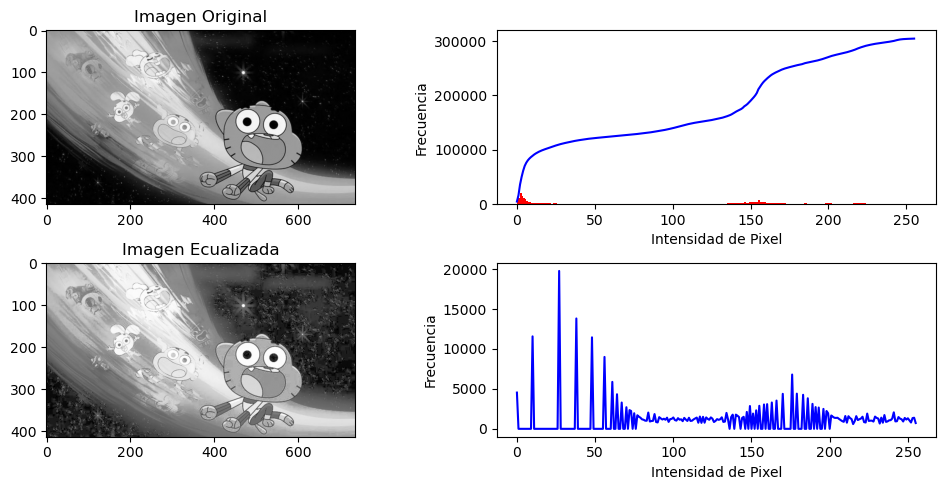

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('gumball.jpg',0)
histograma,calc=np.histogram(img.flatten(),256,[0,256])
disAcum=histograma.cumsum()
disNorm=disAcum*histograma.max()/disAcum.max()

ecualizar=cv2.equalizeHist(img)
histograma_ecu,_=np.histogram(ecualizar.flatten(),256,[0,256])

plt.figure(figsize=(10,5))
plt.subplot(221)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')

plt.subplot(222)
plt.plot(disAcum,color='blue')
plt.xlabel('Intensidad de Pixel')
plt.ylabel('Frecuencia')
##imprimir el histograma por plt
plt.hist(img.flatten(),256,[0,256],color='red')

plt.subplot(223)
plt.imshow(ecualizar,cmap='gray')
plt.title('Imagen Ecualizada')

plt.subplot(224)
plt.plot(histograma_ecu,color='blue')
plt.xlabel('Intensidad de Pixel')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('gumball.jpg')
clip=2.0
tiles=8
clahe=cv2.createCLAHE(clipLimit=clip,tileGridSize=(tiles,tiles))
ecualizado=clahe.apply(image)

plt.figure(figsize=(10,5))
plt.imshow(image,cmap='gray')
plt.title('Imagen Original')
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(ecualizado,cmap='gray')
plt.title('Imagen Ecualizada con CLAHE')
plt.show()


error: OpenCV(4.12.0) C:\Users\dev-admin\buildout\croot\opencv-suite_1765297159650\work\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'


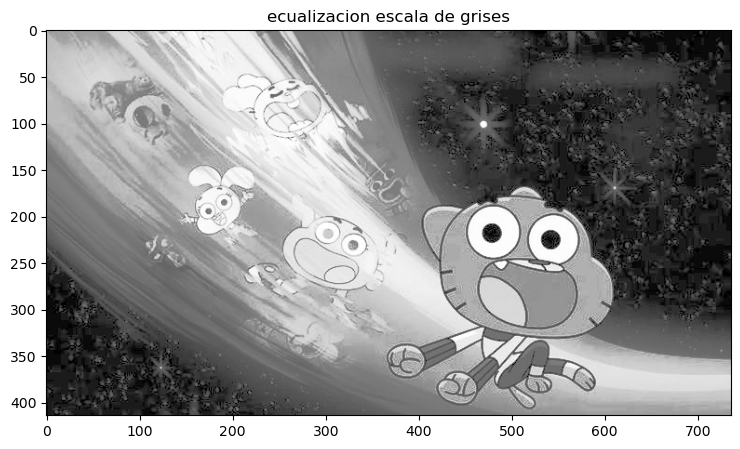

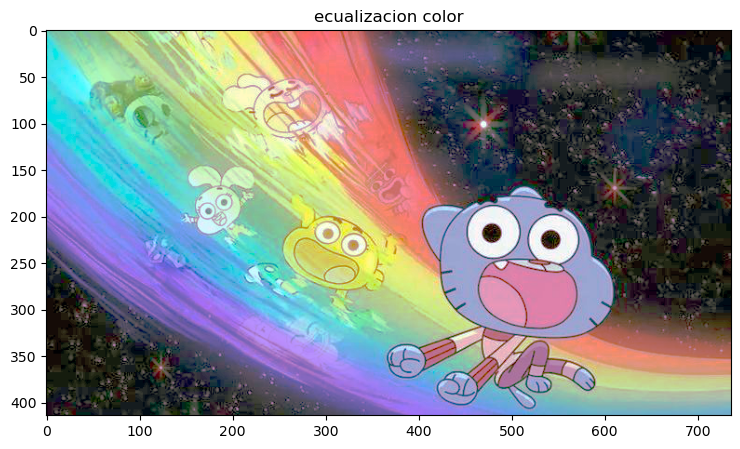

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('gumball.jpg',0)
imge=cv2.imread('gumball.jpg')

ecualizada=cv2.equalizeHist(img)
ecu_color=cv2.merge([cv2.equalizeHist(imge[:,:,0]),cv2.equalizeHist(imge[:,:,1]),cv2.equalizeHist(imge[:,:,2])])

plt.imshow(ecualizada,cmap='gray')
plt.title('ecualizacion escala de grises')
plt.show()

plt.imshow(cv2.cvtColor(ecu_color, cv2.COLOR_BGR2RGB))
plt.title('ecualizacion color')
plt.show()

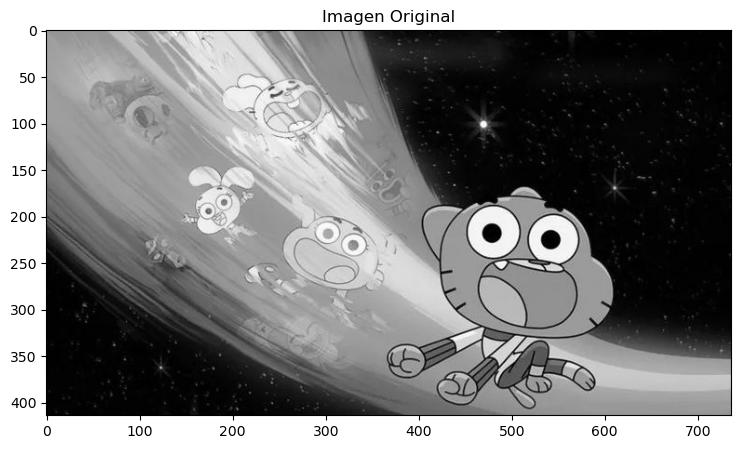

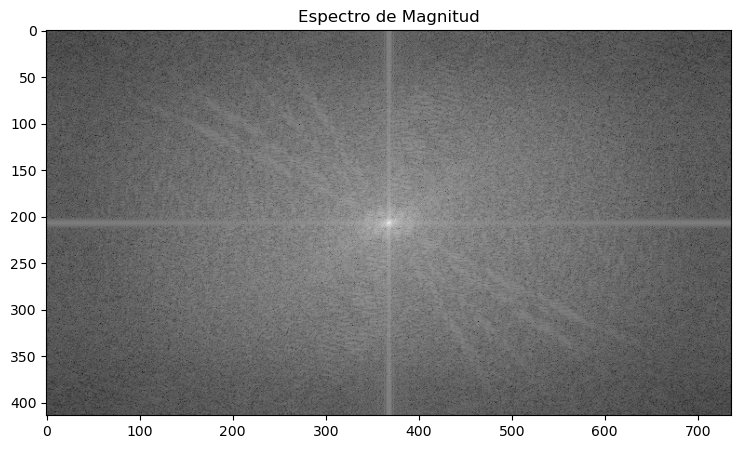

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('gumball.jpg',0)
transformada=np.fft.fft2(img)
desplazamiento=np.fft.fftshift(transformada)
magnitud_espectro=np.log(1+np.abs(desplazamiento))

plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.show()

plt.imshow(magnitud_espectro,cmap='gray')
plt.title('Espectro de Magnitud')
plt.show()